In [16]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scvi
from scipy import sparse
import sys
import os
sys.path.append(os.path.abspath(".."))
from speciesot_helpers import match_cells_by_celltype_tissue, mouse_human_orthologs_biomart

In [2]:
MOUSE_H5AD = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_muris/sampled_mouse_shared.h5ad"
HUMAN_H5AD = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_sapiens/sampled_human_shared.h5ad"

In [3]:
mouse_full = sc.read_h5ad(MOUSE_H5AD)
human_full = sc.read_h5ad(HUMAN_H5AD)

mouse_B = mouse_full.raw.to_adata()
human_B = human_full.raw.to_adata()

mouse_B.obs = mouse_full.obs.copy()
human_B.obs = human_full.obs.copy()

mouse_B = mouse_B[mouse_B.obs['assay']=="10x 3' v2"]
human_B = human_B[human_B.obs['assay']=="10x 3' v3"]

In [6]:
human_B.obs["cell_type"] = human_B.obs["cell_type"].cat.add_categories(["HSPC"])
human_B.obs.loc[human_B.obs["cell_type"].isin(["hematopoietic precursor cell","hematopoietic stem cell"]), "cell_type"] = "HSPC"

/tmp/ipykernel_3492948/3064969281.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  human_B.obs["cell_type"] = human_B.obs["cell_type"].cat.add_categories(["HSPC"])


In [7]:
mouse_matched_B, human_matched_B = match_cells_by_celltype_tissue(
    mouse_B, human_B,
    cell_type_key="cell_type_ontology_term_id",
    tissue_key="tissue_ontology_term_id",
)

for a in [mouse_matched_B, human_matched_B]:
    a.layers["counts"] = a.X.copy()
    a.X = a.X.astype("float32")
    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)

In [8]:
mouse_matched_B

AnnData object with n_obs × n_vars = 4027 × 18024
    obs: 'batch', 'tissue_FACS_droplet', 'free_annotation', 'n_counts', 'n_genes', 'louvain', 'leiden', 'age', 'method', 'donor_id', 'subtissue', 'tissue_free_annotation', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'FACS.selection', 'tissue_original', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'shared_cell_type'
    var: 'index', 'n_cells-0', 'n_cells-1', 'gene_symbols', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'age_colors', 'citation', 'leiden', 'louvain', 'louvain_colors', 'method_colors', 'neighbors', 'organism', 'organism_ontology_term_id', 'pca', 'schema_reference', 'schema_ver

In [9]:
mouse_matched_B.obs['tissue'].value_counts()

tissue
lung               1906
bone marrow         723
spleen              459
heart               270
thymus              226
adipose tissue      119
large intestine      93
mammary gland        85
liver                66
trachea              55
kidney               18
skin of body          7
Name: count, dtype: int64

In [10]:
mouse_matched_B.obs['cell_type'].value_counts()

cell_type
hematopoietic precursor cell       613
intermediate monocyte              504
non-classical monocyte             365
natural killer cell                351
vein endothelial cell              278
fibroblast of cardiac tissue       242
thymocyte                          226
bronchial smooth muscle cell       187
B cell                             153
endothelial cell                   153
basophil                           143
plasma cell                        132
pulmonary alveolar type 2 cell     125
large intestine goblet cell         93
T cell                              76
classical monocyte                  74
macrophage                          69
pericyte                            61
monocyte                            36
CD8-positive, alpha-beta T cell     31
plasmacytoid dendritic cell         27
smooth muscle cell                  27
fibroblast                          26
CD4-positive, alpha-beta T cell     25
myeloid dendritic cell               5
neutrophil     

In [11]:
human_matched_B.obs['cell_type'].value_counts()

cell_type
HSPC                               613
intermediate monocyte              504
non-classical monocyte             365
natural killer cell                351
vein endothelial cell              278
fibroblast of cardiac tissue       242
thymocyte                          226
bronchial smooth muscle cell       187
B cell                             153
endothelial cell                   153
basophil                           143
plasma cell                        132
pulmonary alveolar type 2 cell     125
large intestine goblet cell         93
T cell                              76
classical monocyte                  74
macrophage                          69
pericyte                            61
monocyte                            36
CD8-positive, alpha-beta T cell     31
plasmacytoid dendritic cell         27
smooth muscle cell                  27
fibroblast                          26
CD4-positive, alpha-beta T cell     25
myeloid dendritic cell               5
neutrophil     

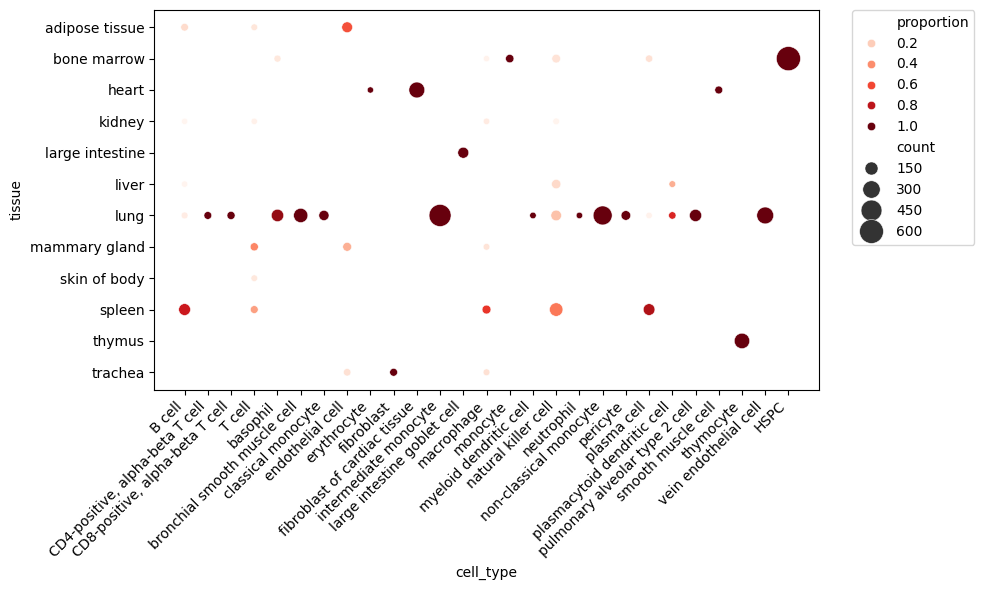

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create contingency table
ct = pd.crosstab(
    human_matched_B.obs['cell_type'],
    human_matched_B.obs['tissue']
)

# Convert to proportions (row-wise: per cell type)
ct_prop = ct.div(ct.sum(axis=1), axis=0)

# Melt for plotting
df_prop = ct_prop.reset_index().melt(
    id_vars='cell_type',
    var_name='tissue',
    value_name='proportion'
)

df_counts = ct.reset_index().melt(
    id_vars='cell_type',
    var_name='tissue',
    value_name='count'
)

# Merge
df = df_prop.copy()
df['count'] = df_counts['count']

# ❗ Remove zero-count entries (no dots)
df = df[df['count'] > 0]

# Plot
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=df,
    x='cell_type',   # flipped
    y='tissue',      # flipped
    size='count',
    hue='proportion',
    sizes=(20, 300),
    palette='Reds'
)

# Rotate x labels for readability
plt.xticks(rotation=45, ha='right')

# Move legend outside
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=labels,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.
)

plt.tight_layout()
plt.show()

In [ ]:
# How many orthologs?
mouse_human_orthologs_biomart(human_B, mouse_B)